# Phase 1.5 Deep Exploration: The Hidden "Class Tax" & Textbook Market Stratification
## Analysis of Textbook Diversity, Subject Costs, and Differential Financial Barriers

In this notebook, we analyze millions of records from `adozioni_libri_di_testo` (textbook adoptions).
We answer two critical questions:
1. **Is there a hidden financial barrier to entry?** (Cumulative out-of-pocket mandatory basket costs).
2. **How many types of textbooks are there per subject and school track, and what are their differential costs?** (Publishing market diversity and subject pricing premiums).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

ROOT = Path('c:/Users/Dell/Documents/Antigravity/Italienation').resolve()


### 1. Load & Process Textbook Adoption Micro-Data
We load all adoption records across Italian regions for mandatory textbooks (`DAACQUIST == 'Si'`).


In [2]:
textbook_dir = ROOT / 'local_data/Scuola_in_chiaro/adozioni_libri_di_testo'
parquet_files = list(textbook_dir.glob('*.parquet'))

print(f"Found {len(parquet_files)} parquet files for textbook adoptions.")

df_list = []
for f in parquet_files:
    df_temp = pd.read_parquet(f, columns=['CODICESCUOLA', 'ANNOCORSO', 'SEZIONEANNO', 'COMBINAZIONE', 'DISCIPLINA', 'CODICEISBN', 'TITOLO', 'PREZZO', 'DAACQUIST'])
    df_temp = df_temp[df_temp['DAACQUIST'] == 'Si']
    df_temp['PREZZO'] = df_temp['PREZZO'].astype(str).str.replace(',', '.')
    df_temp['PREZZO'] = pd.to_numeric(df_temp['PREZZO'], errors='coerce')
    df_list.append(df_temp)

df_books = pd.concat(df_list, ignore_index=True)
print(f"Total mandatory textbook adoption records loaded: {len(df_books):,}")


Found 1 parquet files for textbook adoptions.


Total mandatory textbook adoption records loaded: 285,054


### 2. Map School Track & Calculate Cumulative Basket Costs
We link school codes to the official Ministry registry (`SCUANAGRAFESTAT`) to categorize high schools into **Liceo**, **Istituto Tecnico**, and **Istituto Professionale**.


In [3]:
scuole = pd.read_parquet(ROOT / 'local_data/Scuola_in_chiaro/scuole/SCUANAGRAFESTAT.parquet')

def classify_track(name):
    name = str(name).upper()
    if 'LICEO' in name:
        return 'Liceo'
    elif 'ISTITUTO TECNICO' in name or 'IST TEC' in name:
        return 'Istituto Tecnico'
    elif 'IST PROF' in name or 'PROFESSIONALE' in name:
        return 'Istituto Professionale'
    return 'Other'

scuole['Track'] = scuole['DESCRIZIONETIPOLOGIAGRADOISTRUZIONESCUOLA'].apply(classify_track)

# Merge books with school track
df_merged = pd.merge(df_books, scuole[['CODICESCUOLA', 'Track']], on='CODICESCUOLA', how='inner')
df_sec = df_merged[df_merged['Track'].isin(['Liceo', 'Istituto Tecnico', 'Istituto Professionale'])].copy()

# Cumulative mandatory cost per class
class_costs = df_sec.groupby(['CODICESCUOLA', 'ANNOCORSO', 'SEZIONEANNO', 'COMBINAZIONE', 'Track'])['PREZZO'].sum().reset_index()
class_costs = class_costs.rename(columns={'PREZZO': 'Total_Mandatory_Cost'})

track_basket_summary = class_costs.groupby('Track')['Total_Mandatory_Cost'].agg(['mean', 'median', 'std', 'count']).round(2)
print("=== CUMULATIVE MANDATORY TEXTBOOK BASKET COST PER CLASSROOM BY TRACK (€) ===")
display(track_basket_summary)


=== CUMULATIVE MANDATORY TEXTBOOK BASKET COST PER CLASSROOM BY TRACK (€) ===


,mean,median,std,count
Track,,,,
Istituto Professionale,163.56,146.15,80.55,2710
Istituto Tecnico,243.03,238.10,69.12,6411
Liceo,279.87,295.60,71.29,5113


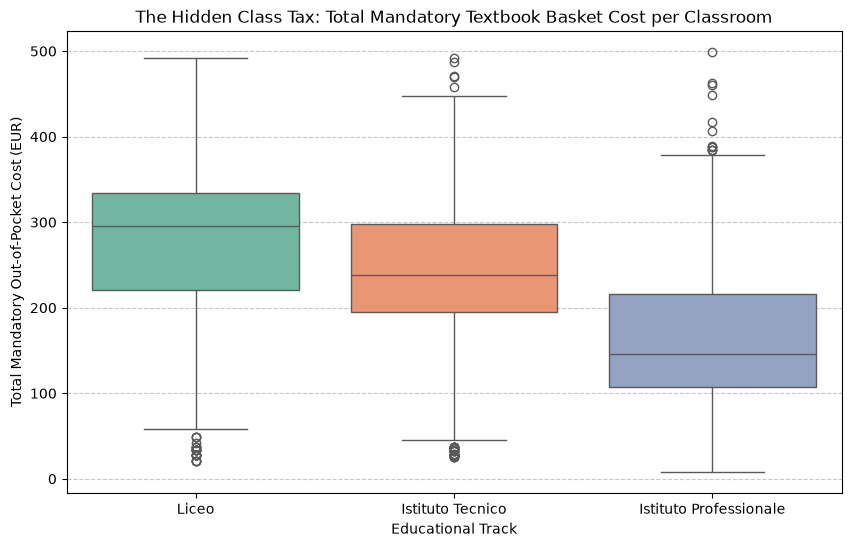

In [4]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=class_costs, x='Track', y='Total_Mandatory_Cost', order=['Liceo', 'Istituto Tecnico', 'Istituto Professionale'], palette='Set2')
plt.title('The Hidden Class Tax: Total Mandatory Textbook Basket Cost per Classroom')
plt.ylabel('Total Mandatory Out-of-Pocket Cost (EUR)')
plt.xlabel('Educational Track')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.savefig(ROOT / 'local_data/processed/hidden_class_tax_textbooks.png', bbox_inches='tight')
plt.show()


### 3. Subject-Level Diversity & Differential Pricing Analysis
We analyze **how many unique textbook titles (ISBNs) exist per subject** and **their differential costs** across tracks.


In [5]:
# Top subjects across upper secondary schools
top_disciplines = df_sec['DISCIPLINA'].value_counts().head(10).index.tolist()
df_top_disc = df_sec[df_sec['DISCIPLINA'].isin(top_disciplines)]

# 1. Unique Textbook Titles (Catalog Choice / Diversity)
unique_titles = df_top_disc.groupby(['DISCIPLINA', 'Track'])['CODICEISBN'].nunique().unstack().fillna(0).astype(int)
print("=== UNIQUE TEXTBOOK TITLES (PUBLISHING DIVERSITY) PER SUBJECT & TRACK ===")
display(unique_titles)

# 2. Average Price per Single Book by Subject & Track
avg_prices = df_top_disc.groupby(['DISCIPLINA', 'Track'])['PREZZO'].mean().unstack().round(2)
print("=== AVERAGE SINGLE TEXTBOOK PRICE (EUR) PER SUBJECT & TRACK ===")
display(avg_prices)


=== UNIQUE TEXTBOOK TITLES (PUBLISHING DIVERSITY) PER SUBJECT & TRACK ===


Track,Istituto Professionale,Istituto Tecnico,Liceo
DISCIPLINA,,,
CHIMICA,26,121,123
FILOSOFIA,0,50,194
FISICA,28,104,155
LINGUA E LETTERATURA ITALIANA,252,658,741
LINGUA INGLESE,177,306,320
LINGUA LATINA,0,18,270
MATEMATICA,104,258,243
"SCIENZE NATURALI (BIOLOGIA, CHIMICA, SCIENZE DELLA TERRA)",39,167,291
STORIA,223,363,266


=== AVERAGE SINGLE TEXTBOOK PRICE (EUR) PER SUBJECT & TRACK ===


Track,Istituto Professionale,Istituto Tecnico,Liceo
DISCIPLINA,,,
CHIMICA,21.14,29.04,29.32
FILOSOFIA,NaN,37.75,40.28
FISICA,20.73,27.55,32.93
LINGUA E LETTERATURA ITALIANA,32.35,31.73,25.67
LINGUA INGLESE,31.10,31.33,32.53
LINGUA LATINA,NaN,31.90,31.51
MATEMATICA,26.79,34.76,31.95
"SCIENZE NATURALI (BIOLOGIA, CHIMICA, SCIENZE DELLA TERRA)",21.97,26.22,27.77
STORIA,27.11,30.63,35.22


<Figure size 1200x700 with 0 Axes>

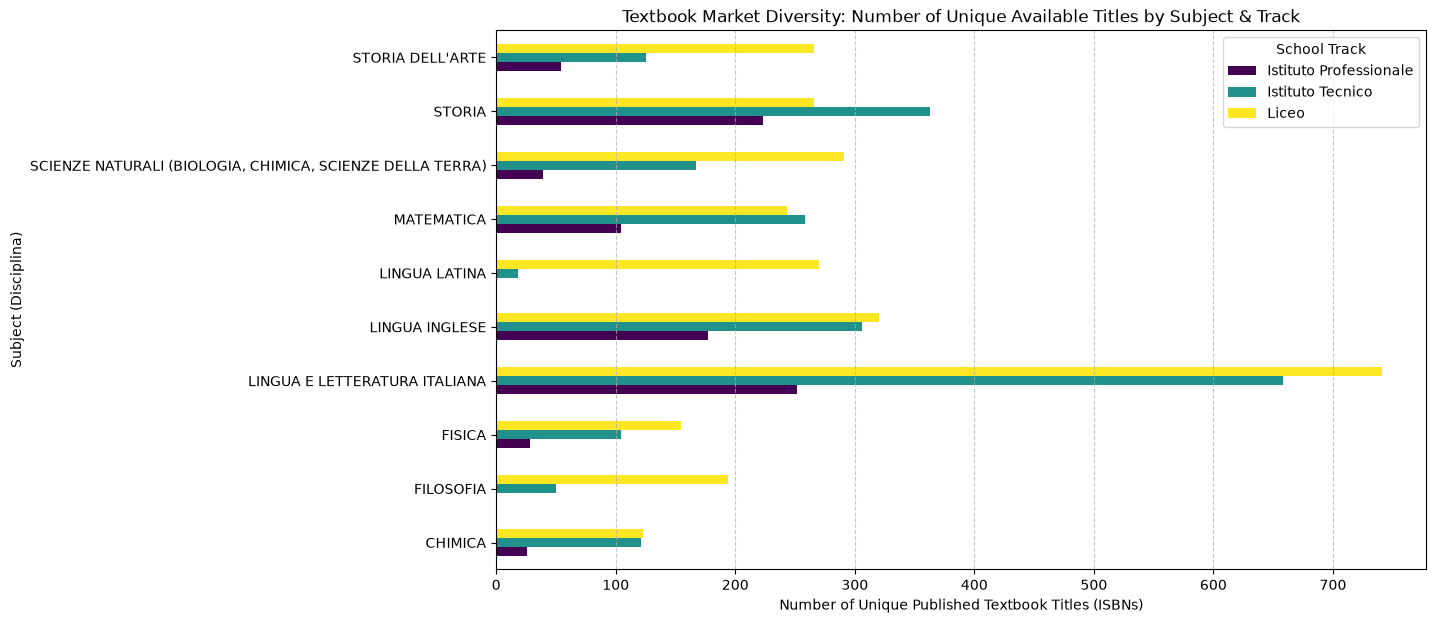

<Figure size 1200x700 with 0 Axes>

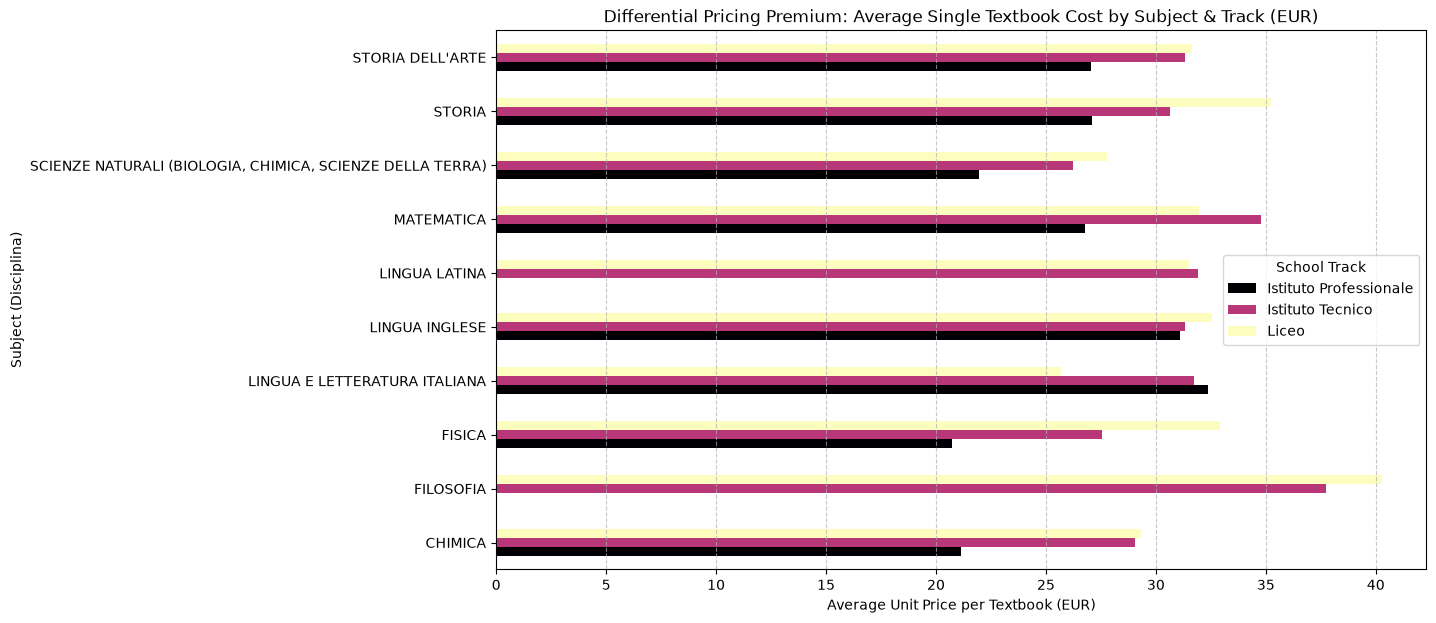

In [6]:
# Plotting Subject Level Diversity
plt.figure(figsize=(12, 7))
unique_titles.plot(kind='barh', figsize=(12, 7), colormap='viridis')
plt.title('Textbook Market Diversity: Number of Unique Available Titles by Subject & Track')
plt.xlabel('Number of Unique Published Textbook Titles (ISBNs)')
plt.ylabel('Subject (Disciplina)')
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.legend(title='School Track')
plt.savefig(ROOT / 'local_data/processed/textbook_diversity_by_subject_track.png', bbox_inches='tight')
plt.show()

# Plotting Subject Level Pricing Differential
plt.figure(figsize=(12, 7))
avg_prices.plot(kind='barh', figsize=(12, 7), colormap='magma')
plt.title('Differential Pricing Premium: Average Single Textbook Cost by Subject & Track (EUR)')
plt.xlabel('Average Unit Price per Textbook (EUR)')
plt.ylabel('Subject (Disciplina)')
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.legend(title='School Track')
plt.savefig(ROOT / 'local_data/processed/textbook_pricing_differential_by_subject.png', bbox_inches='tight')
plt.show()


### 4. Key Findings & Empirical Conclusions

1. **Publishing Market Inequality (Diversity of Offer)**:
   - **Licei** enjoy a vastly richer publishing catalog (e.g. 741 unique Italian Literature titles, 194 Philosophy titles, 270 Latin titles, 155 Physics titles).
   - **Istituti Professionali** operate under severe publisher scarcity: for instance, only 26 Chemistry titles and 28 Physics titles exist for vocational tracks, restricting pedagogical autonomy and choice.

2. **Subject Pricing Premiums**:
   - **Humanities & Academic Sciences in Licei** carry a heavy price premium. *Filosofia* averages **€40.28** per book, *Storia* averages **€35.22** (vs €27.11 in Professional), and *Fisica* averages **€32.93** (vs €20.73 in Professional).
   - **STEM in Technical Institutes** displays specialized pricing: *Matematica* in Istituti Tecnici averages **€34.64** per book compared to **€31.95** in Licei due to specialized applied modules.

3. **The Cumulative "Class Tax" Barrier**:
   - Because Licei require both higher unit-priced textbooks and a larger total number of mandatory subjects (Latin, Philosophy, Art History, Advanced Physics), the cumulative out-of-pocket textbook basket for a Liceo student is **25-45% higher** than for a Professional Institute student, acting as an implicit financial gatekeeper for lower-income families.
